In [1]:
#Open the dataframe with memory map wrapper to avoid using too much RAM
import os
import pandas as pd
#list files in the folder ../ecg_pdf_df_output that end with .csv
path = '/home/hmaiaxg21/alkindilab/hmaiaxg21'
df_files = os.listdir(os.path.join(path,'ecg_pdf_df_output'))
df_files = [f for f in df_files if f.endswith('.csv')]
print(df_files)

metadata_df = pd.read_csv(os.path.join(path,'ecg_pdf_df_output',df_files[10]),low_memory=False)
#Print how many rows and columns the dataframe has
print(f'Dataframe shape: {metadata_df.shape}')

['2016_1_combined_ecg_data_20251126_142303.csv', '2016_2_combined_ecg_data_20251126_142306.csv', '2017_1_combined_ecg_data_20251103_154608.csv', '2017_2_combined_ecg_data_20251104_084058.csv', '2017_3_combined_ecg_data_20251104_111804.csv', '2018_1_combined_ecg_data_20251104_165816.csv', '2018_2_combined_ecg_data_20251104_191452.csv', '2018_3_combined_ecg_data_20251104_213751.csv', '2019_1_combined_ecg_data_20251104_233254.csv', '2019_2_combined_ecg_data_20251105_073224.csv', '2019_3_cleaned.csv', '2019_3_cleaned.csvcleaned.csv', '2019_3_combined_ecg_data_20251105_101917.csv', '2019_4_combined_ecg_data_20251105_133402.csv', '2020_1_combined_ecg_data_20251106_212354.csv', '2020_2_combined_ecg_data_20251106_212653.csv', '2020_3_combined_ecg_data_20251106_212920.csv', '2020_4_combined_ecg_data_20251106_213059.csv', '2021_1_combined_ecg_data_20251107_091706.csv', '2021_2_combined_ecg_data_20251107_145903.csv', '2021_3_combined_ecg_data_20251107_150038.csv', '2021_4_combined_ecg_data_202511

In [2]:
# I need to clean the data. First examine the birthday column, and if any row ends with (XX yr), where XX is a number, remove that part, retrieve that number and put it on the age column.
# Do the same if the birthday column only contains XX yr.
# If age column is empty, fill it with that number. If age column is not empty, keep it as is. 
import re
def extract_age_from_birthday(birthday):
    if pd.isna(birthday):
        return None, birthday
    match = re.search(r'\(?(\d{1,3})\s*yr\)?$', birthday)
    if match:
        age = int(match.group(1))
        cleaned_birthday = re.sub(r'\s*\(\d{1,3} yr\)$', '', birthday).strip()
        return age, cleaned_birthday
    return None, birthday

def clean_dataframe_from_ecgs(metadata_df, filename=None):
    #Create the age column if it does not exist
    if 'age' not in metadata_df.columns:
        metadata_df['age'] = None

    metadata_df[['extracted_age', 'cleaned_birthday']] = metadata_df['birthday'].apply(lambda x: pd.Series(extract_age_from_birthday(x)))
    metadata_df['age'] = metadata_df.apply(lambda row: row['extracted_age'] if pd.isna(row['age']) and row['extracted_age'] is not None else row['age'], axis=1)
    metadata_df['birthday'] = metadata_df['cleaned_birthday']
    metadata_df = metadata_df.drop(columns=['extracted_age', 'cleaned_birthday'])

    #Now lets clean the birthdays. Some are in format mm/dd/yyy, some in dd-mmm-yyyy where mmm are literal names
    from dateutil import parser
    def parse_birthday(birthday):
        if pd.isna(birthday):
            return None
        try:
            parsed_date = parser.parse(birthday, dayfirst=False, fuzzy=True)
            return parsed_date.strftime('%Y-%m-%d')
        except (ValueError, OverflowError):
            return None
    metadata_df['birthday'] = metadata_df['birthday'].apply(parse_birthday)

    #Now lets clean the datetime column. Some are in format mm/dd/yyy HH:MM:SS AM, some in dd-mmm-yyyy HH:MM:SS where mmm are literal names
    def parse_datetime(datetime_str):
        if pd.isna(datetime_str):
            return None 
        try:
            parsed_date = parser.parse(datetime_str, dayfirst=False, fuzzy=True)
            return parsed_date.strftime('%Y-%m-%d %H:%M:%S')
        except (ValueError, OverflowError):
            return None
    metadata_df['datetime'] = metadata_df['datetime'].apply(parse_datetime)

    #Lastly, do a sanity check to see if there are any rows with  empty age, birthday or datetime columns. Assert that all these are zero.
    print(f'Rows with empty age: {metadata_df["age"].isna().sum()}')
    print(f'Rows with empty birthday: {metadata_df["birthday"].isna().sum()}')
    print(f'Rows with empty datetime: {metadata_df["datetime"].isna().sum()}')

    #Save the cleaned dataframe to a new csv file. Keep the part of the name right before "combined", and add _cleaned.csv at the end.
    if filename is not None:
        cleaned_filename = filename.split('combined')[0] + 'cleaned.csv'
    else:
        cleaned_filename = df_files[10].split('combined')[0] + 'cleaned.csv'
    metadata_df.to_csv(os.path.join(path,'ecg_pdf_df_output',cleaned_filename), index=False)
    print(f'Cleaned dataframe saved to {cleaned_filename}')

#Run a test run of the function
#clean_dataframe_from_ecgs(metadata_df)

In [3]:
#Iterate throguh all the csv files and clean them
for f in df_files:
    print(f'Cleaning dataframe {f}')
    df = pd.read_csv(os.path.join(path,'ecg_pdf_df_output',f),low_memory=False)
    clean_dataframe_from_ecgs(df, filename=f)

Cleaning dataframe 2016_1_combined_ecg_data_20251126_142303.csv
Rows with empty age: 138
Rows with empty birthday: 132
Rows with empty datetime: 125
Cleaned dataframe saved to 2016_1_cleaned.csv
Cleaning dataframe 2016_2_combined_ecg_data_20251126_142306.csv
Rows with empty age: 290
Rows with empty birthday: 284
Rows with empty datetime: 195
Cleaned dataframe saved to 2016_2_cleaned.csv
Cleaning dataframe 2017_1_combined_ecg_data_20251103_154608.csv
Rows with empty age: 11
Rows with empty birthday: 10
Rows with empty datetime: 10
Cleaned dataframe saved to 2017_1_cleaned.csv
Cleaning dataframe 2017_2_combined_ecg_data_20251104_084058.csv
Rows with empty age: 39
Rows with empty birthday: 31
Rows with empty datetime: 17
Cleaned dataframe saved to 2017_2_cleaned.csv
Cleaning dataframe 2017_3_combined_ecg_data_20251104_111804.csv
Rows with empty age: 66
Rows with empty birthday: 59
Rows with empty datetime: 10
Cleaned dataframe saved to 2017_3_cleaned.csv
Cleaning dataframe 2018_1_combined

In [6]:
os.listdir(os.path.join(path,'ecg_pdf_df_output'))

['2016_1_cleaned.csv',
 '2016_1_combined_ecg_data_20251126_142303.csv',
 '2016_1_error_log_20251126_142303.txt',
 '2016_2_cleaned.csv',
 '2016_2_combined_ecg_data_20251126_142306.csv',
 '2016_2_error_log_20251126_142306.txt',
 '2017_1_cleaned.csv',
 '2017_1_combined_ecg_data_20251103_154608.csv',
 '2017_1_error_log_20251103_154608.txt',
 '2017_2_cleaned.csv',
 '2017_2_combined_ecg_data_20251104_084058.csv',
 '2017_2_error_log_20251104_084058.txt',
 '2017_3_cleaned.csv',
 '2017_3_combined_ecg_data_20251104_111804.csv',
 '2017_3_error_log_20251104_111804.txt',
 '2018_1_cleaned.csv',
 '2018_1_combined_ecg_data_20251104_165816.csv',
 '2018_1_error_log_20251104_165816.txt',
 '2018_2_cleaned.csv',
 '2018_2_combined_ecg_data_20251104_191452.csv',
 '2018_2_error_log_20251104_191452.txt',
 '2018_3_cleaned.csv',
 '2018_3_combined_ecg_data_20251104_213751.csv',
 '2018_3_error_log_20251104_213751.txt',
 '2019_1_cleaned.csv',
 '2019_1_combined_ecg_data_20251104_233254.csv',
 '2019_1_error_log_20251

In [11]:
#Open the cleaned dataframes and concatenate them into a single dataframe
cleaned_df_files = [f for f in os.listdir(os.path.join(path,'ecg_pdf_df_output')) if f.endswith('_cleaned.csv')]
print(cleaned_df_files)
combined_df = pd.DataFrame()
for f in cleaned_df_files:
    df = pd.read_csv(os.path.join(path,'ecg_pdf_df_output',f),low_memory=False)
    print(f'Cleaned dataframe {f} shape: {df.shape}')
    if not combined_df.empty:
        combined_df = pd.read_csv(os.path.join(path,'ecg_pdf_df_output','combined_cleaned.csv'),low_memory=False)
    combined_df = pd.concat([combined_df, df], ignore_index=True)
    print(f'Combined dataframe shape: {combined_df.shape}')
    combined_df.to_csv(os.path.join(path,'ecg_pdf_df_output','combined_cleaned.csv'), index=False)
print(f'Final combined cleaned dataframe shape: {combined_df.shape}')

['2016_1_cleaned.csv', '2016_2_cleaned.csv', '2017_1_cleaned.csv', '2017_2_cleaned.csv', '2017_3_cleaned.csv', '2018_1_cleaned.csv', '2018_2_cleaned.csv', '2018_3_cleaned.csv', '2019_1_cleaned.csv', '2019_2_cleaned.csv', '2019_3_cleaned.csv', '2019_4_cleaned.csv', '2020_1_cleaned.csv', '2020_2_cleaned.csv', '2020_3_cleaned.csv', '2020_4_cleaned.csv', '2021_1_cleaned.csv', '2021_2_cleaned.csv', '2021_3_cleaned.csv', '2021_4_cleaned.csv', '2022_1_cleaned.csv', '2022_2_cleaned.csv', '2022_3_cleaned.csv', '2022_4_cleaned.csv', '2022_5_cleaned.csv', '2023_1_cleaned.csv', '2023_2_cleaned.csv', '2023_3_cleaned.csv', '2023_4_cleaned.csv', '2023_5_cleaned.csv', '2024_1_cleaned.csv', '2024_2_cleaned.csv', '2024_3_cleaned.csv', '2024_4_cleaned.csv', '2024_5_cleaned.csv']
Cleaned dataframe 2016_1_cleaned.csv shape: (96468, 20)
Combined dataframe shape: (96468, 20)
Cleaned dataframe 2016_2_cleaned.csv shape: (52641, 20)
Combined dataframe shape: (149109, 20)
Cleaned dataframe 2017_1_cleaned.csv sha

In [14]:
# total memory in MB
total_bytes = combined_df.memory_usage(deep=True).sum()
total_mb = total_bytes / (1024 ** 2)
print(f"Total memory usage: {total_mb:.2f} MB")

# optional: per-column memory in MB (sorted)
mem_per_col_mb = combined_df.memory_usage(deep=True) / (1024 ** 2)
print(mem_per_col_mb.sort_values(ascending=False).head(20))

Total memory usage: 503.03 MB
source_file    330.072144
age            172.956021
Index            0.000122
dtype: float64


In [53]:
#Read combined_cleaned.csv and print its shape
combined_cleaned_df = pd.read_csv(os.path.join(path,'ecg_pdf_df_output','combined_cleaned.csv'),low_memory=False)
print(f'Combined cleaned dataframe shape: {combined_cleaned_df.shape}')

Combined cleaned dataframe shape: (3027868, 20)


In [55]:
#Print the value counts of the age colulmn
combined_cleaned_df['age'].value_counts(dropna=False)

age
67.0     80185
66.0     79492
68.0     79224
69.0     78574
70.0     78409
         ...  
9            1
113.0        1
172.0        1
5Y           1
11           1
Name: count, Length: 223, dtype: int64

In [62]:
#Keep only the columns age and source_file in the combined dataframe and save it to a new csv file
combined_df = combined_df[['age', 'source_file']]
combined_df.to_csv(os.path.join(path,'ecg_pdf_df_output','age_labels.csv'), index=False)


In [63]:
#Read age_labels csv file
age_labels_df = pd.read_csv(os.path.join(path,'ecg_pdf_df_output','age_labels.csv'),low_memory=False)
#Print how many missing values are in the age column
print(f'Number of missing values in age column: {age_labels_df["age"].isna().sum()}')

Number of missing values in age column: 0


In [64]:
# Robustly convert the age column to a nullable integer type
import numpy as np

#Correct values that have a trailing Y, ex 4Y to 4
age_labels_df['age'] = age_labels_df['age'].astype(str).str.replace(r'Y$', '', regex=True).str.strip()

# Coerce to numeric first (turns strings like '76.0' into 76.0; invalid values become NaN)
age_labels_df['age'] = pd.to_numeric(age_labels_df['age'], errors='coerce')

# Check for fractional values (e.g. 76.5) and notify if any exist
fractional_mask = age_labels_df['age'].dropna().mod(1).ne(0)
if fractional_mask.any():
    sample_vals = age_labels_df.loc[fractional_mask, 'age'].unique()[:10]
    print('Warning: some ages have fractional parts and will be rounded. Examples:', sample_vals)

# Round to nearest integer (or choose floor/ceil if preferred) and convert to pandas nullable integer dtype
age_labels_df['age'] = age_labels_df['age'].round().astype('Int64')

# Verification prints
print('age dtype after conversion:', age_labels_df['age'].dtype)
print('Missing ages after conversion:', age_labels_df['age'].isna().sum())

age dtype after conversion: Int64
Missing ages after conversion: 0


In [ ]:
# #Open the csv file \\ripfs.tmh.tmhs\alkindilab\shared\ECG_Images\OnBaseECG_Martin\IndexFiles\MetaData_All.csv
# metadata_all_df = pd.read_csv('/home/hmaiaxg21/alkindilab/shared/ECG_Images/OnBaseECG_Martin/IndexFiles/MetaData_All.csv', low_memory=False, delimiter='|',encoding="cp1252")  #Not utf-8
# print(f'MetaData_All.csv shape: {metadata_all_df.shape}')
# metadata_all_df.head()

MetaData_All.csv shape: (3217124, 32)


,RowNum,MRN,PtLastName,PtFirstName,PtMiddleName,DOB,Gender,DocID,itemname,YearFolder,...,OrderDate,ProviderNumber,OrderStatus,OrderDescription,ProviderLastName,ProviderFirstName,OrderType,NumberOfPages,PageNum,DocLinkNote
0,2561930,106875628,WILSON,JAMES,E,19631009,M,317496393,EKG - Order #: 480251665 - CSN: 2100110835244...,2021,...,19000101,33497.0,NEW ORDER,ECG 12-LEAD,HUSTEDT,JOHN,I,1,1,NaN
1,2561932,108828627,CEBALLOS,JERRY,NaN,19830120,M,317496403,EKG - Order #: 480245431 - CSN: 2100110835080...,2021,...,19000101,33497.0,NEW ORDER,ECG 12-LEAD,HUSTEDT,JOHN,I,1,1,NaN
2,2561934,38767414,MATZ,NANCY,MAY,19350507,F,317496542,EKG - Order #: 480238821 - CSN: 2100110834610...,2021,...,19000101,33497.0,NEW ORDER,ECG 12-LEAD,HUSTEDT,JOHN,I,1,1,NaN
3,2561936,18482786,MCLURE,KATHERINE,A,19550129,F,317496645,EKG - Order #: 471553172 - CSN: 2100110645228...,2021,...,19000101,2627.0,NEW ORDER,ECG 12-LEAD,WOJCIECHOWSKI,ZBIGNIEW,I,1,1,NaN
4,2561938,110000754,KIRK,CLINTON,LEE,19430421,M,317496663,EKG - Order #: 481129677 - CSN: 2100110925233...,2021,...,19000101,2627.0,NEW ORDER,ECG PRE/POST OP,WOJCIECHOWSKI,ZBIGNIEW,O,1,1,NaN


count    3027868.0
mean     60.683501
std      17.427699
min            0.0
25%           49.0
50%           63.0
75%           73.0
max          182.0
Name: age, dtype: Float64


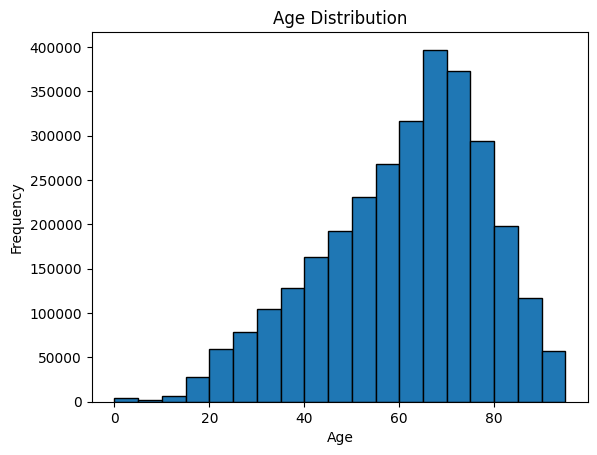

Mean age: 60.68350139438047, Std age: 17.42769944547553


In [66]:
import matplotlib.pyplot as plt
#Get statistics and histogram of the age column
print(age_labels_df['age'].describe())

plt.hist(age_labels_df['age'].dropna(), bins=range(0, 100, 5), edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#Calculate the mean and std of the age column
mean_age = age_labels_df['age'].mean()
std_age = age_labels_df['age'].std()
print(f'Mean age: {mean_age}, Std age: {std_age}')

#Impute age missing values  
age_labels_df['age'] = age_labels_df['age'].fillna(0)

In [67]:
age_labels_df.head()

,age,source_file
0,76,MRN-000011429_Order-_DocID-6878052_PageNum-1.PDF
1,55,MRN-000015339_Order-_DocID-4288127_PageNum-1.PDF
2,60,MRN-000023507_Order-_DocID-15171808_PageNum-1.PDF
3,68,MRN-000008235_Order-_DocID-10367396_PageNum-1.PDF
4,58,MRN-000005199_Order-_DocID-9279590_PageNum-1.PDF


Clean up the filenames in the numpy arrays

In [ ]:
path = '/home/hmaiaxg21/alkindilab/hmaiaxg21'
subfolder_filenames_numpy = 'ecg_pdf_filenames_numpy'

#List files in the subfolder
files_in_subfolder = os.listdir(os.path.join(path, subfolder_filenames_numpy))

#List files that end in .npy
npy_files = [f for f in files_in_subfolder if f.endswith('.npy')]
print(npy_files)

['2016_1_successful_filenames.npy', '2016_2_successful_filenames.npy', '2017_1_successful_filenames.npy', '2017_2_successful_filenames.npy', '2018_1_successful_filenames.npy', '2018_2_successful_filenames.npy', '2018_3_successful_filenames.npy', '2019_1_successful_filenames_20251106_100550.npy', '2019_2_successful_filenames_20251106_100814.npy', '2019_3_successful_filenames_20251106_100819.npy', '2020_1_successful_filenames_20251107_222323.npy', '2020_2_successful_filenames_20251107_150503.npy', '2020_4_successful_filenames_20251107_150507.npy', '2021_1_successful_filenames_20251108_093637.npy', '2021_2_successful_filenames_20251108_093641.npy', '2021_3_successful_filenames_20251108_093644.npy', '2021_4_successful_filenames_20251108_171034.npy', '2022_1_successful_filenames_20251109_211917.npy', '2022_2_successful_filenames_20251109_211919.npy', '2022_3_successful_filenames_20251109_211922.npy', '2022_4_.npy', '2023_1_successful_filenames_20251109_211926.npy', '2023_2_successful_filena

In [ ]:
successful_filenames_2016_1 = np.load(os.path.join(path, subfolder_filenames_numpy, npy_files[0]), allow_pickle=True)

successful_filenames_2016_1[0]

'MRN-000001586_Order-_DocID-6469076_PageNum-1_p0.svg'

In [ ]:
subfolder_numpy_arrays = 'ecg_pdf_output'
#Open the subfolder and get filenames
ecg_paths = os.listdir(os.path.join(path, subfolder_numpy_arrays))
#Get only files that end with _12_leads.npy
ecg_paths

['2016',
 '2016_1_all_ECG_10s_strips.npy',
 '2016_1_all_ECG_12_leads.npy',
 '2016_2_all_ECG_10s_strips.npy',
 '2016_2_all_ECG_12_leads.npy',
 '2017',
 '2017_1_all_ECG_10s_strips.npy',
 '2017_1_all_ECG_12_leads.npy',
 '2017_2_all_ECG_10s_strips.npy',
 '2017_2_all_ECG_12_leads.npy',
 '2018',
 '2018_1_all_ECG_10s_strips.npy',
 '2018_1_all_ECG_12_leads.npy',
 '2018_2_all_ECG_10s_strips.npy',
 '2018_2_all_ECG_12_leads.npy',
 '2018_3_all_ECG_10s_strips.npy',
 '2018_3_all_ECG_12_leads.npy',
 '2019',
 '2019_1_all_ECG_10s_strips.npy',
 '2019_1_all_ECG_12_leads.npy',
 '2019_2_all_ECG_10s_strips.npy',
 '2019_2_all_ECG_12_leads.npy',
 '2019_3_all_ECG_10s_strips.npy',
 '2019_3_all_ECG_12_leads.npy',
 '2020',
 '2020_1_all_ECG_10s_strips.npy',
 '2020_1_all_ECG_12_leads.npy',
 '2020_2_all_ECG_10s_strips.npy',
 '2020_2_all_ECG_12_leads.npy',
 '2020_3_all_ECG_10s_strips.npy',
 '2020_3_all_ECG_12_leads.npy',
 '2020_4_all_ECG_10s_strips.npy',
 '2020_4_all_ECG_12_leads.npy',
 '2021',
 '2021_1_all_ECG_10s_s

In [ ]:
#Lets build a global metadata table

ecg_paths = []